In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [2]:
df=pd.read_csv('/kaggle/input/datasets/nabinpaaudel/traind/train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [5]:
#df['Age'].fillna(df['Age'].mean(),inplace=True)
df.fillna({'Age':df['Age'].mean()},inplace=True)

In [6]:
X=df.iloc[:,1:3]
y=df.iloc[:,0]

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

/tmp/ipykernel_152/2150678065.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


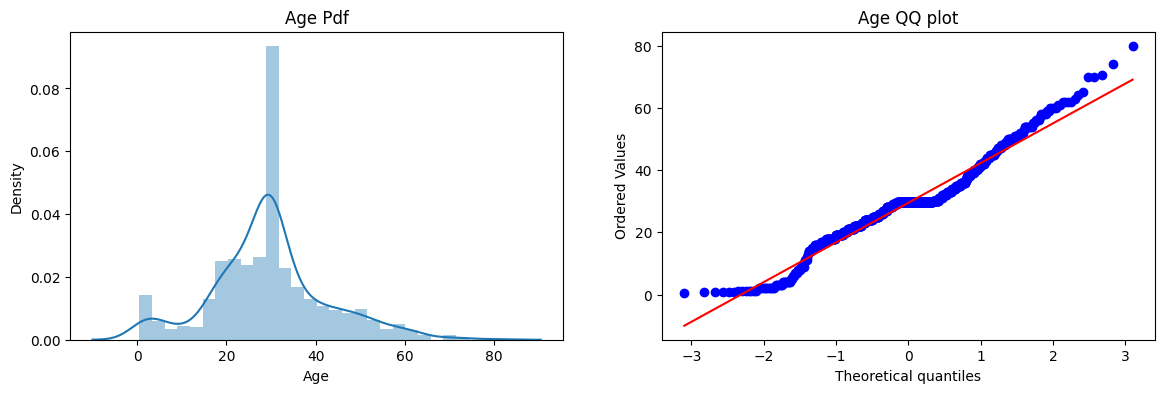

In [8]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age Pdf')

plt.subplot(122)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age QQ plot')
plt.show()

/tmp/ipykernel_152/90668344.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


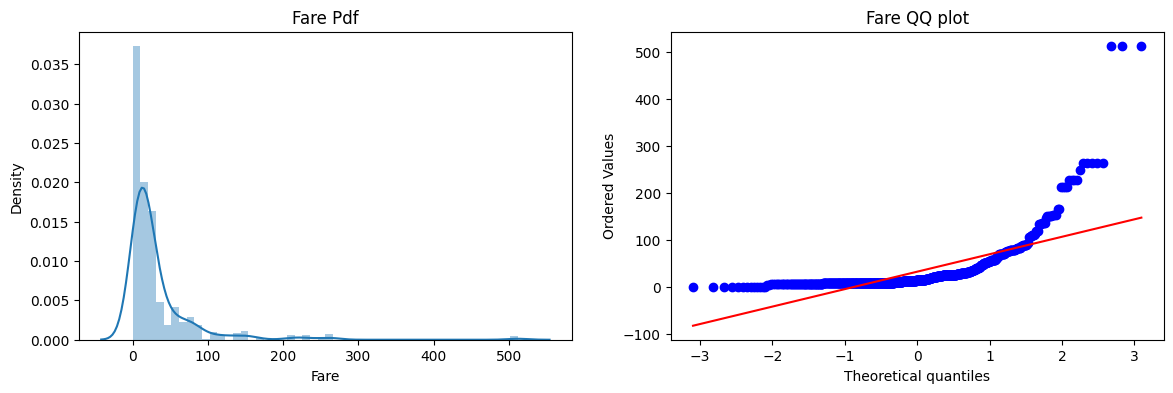

In [9]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Fare'])
plt.title('Fare Pdf')

plt.subplot(122)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('Fare QQ plot')
plt.show()

In [10]:
clf=LogisticRegression()
DT=DecisionTreeClassifier()

In [11]:
clf.fit(X_train,y_train)
DT.fit(X_train,y_train)

y_pred_clf=clf.predict(X_test)
y_pred_DT=DT.predict(X_test)

In [12]:
print('Accuracy LR',accuracy_score(y_test,y_pred_clf))
print('Accuracy DT',accuracy_score(y_test,y_pred_DT))

Accuracy LR 0.6480446927374302
Accuracy DT 0.6815642458100558


In [14]:
trf=FunctionTransformer(func=np.log1p)

In [15]:
X_train_transformed=trf.fit_transform(X_train)
X_test_transformed=trf.transform(X_test)

In [17]:
clf1=LogisticRegression()
clf2=DecisionTreeClassifier()
clf1.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

DecisionTreeClassifier()

In [19]:
y_pred_clf1=clf1.predict(X_test_transformed)
y_pred_clf2=clf2.predict(X_test_transformed)

In [20]:
print('Accuracy_LR',accuracy_score(y_test,y_pred_clf1))
print('Accuracy DT',accuracy_score(y_test,y_pred_clf2))

Accuracy_LR 0.6815642458100558
Accuracy DT 0.6871508379888268


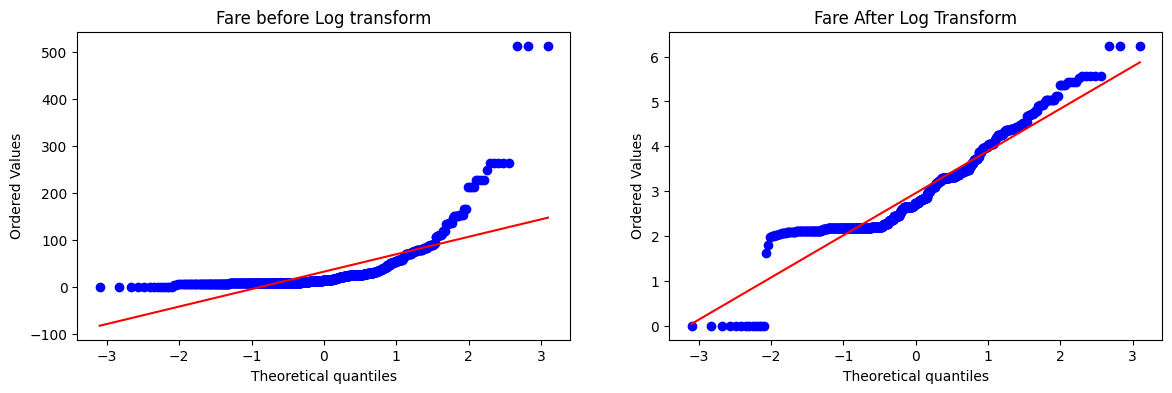

In [21]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('Fare before Log transform')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'],dist='norm',plot=plt)
plt.title('Fare After Log Transform')
plt.show()

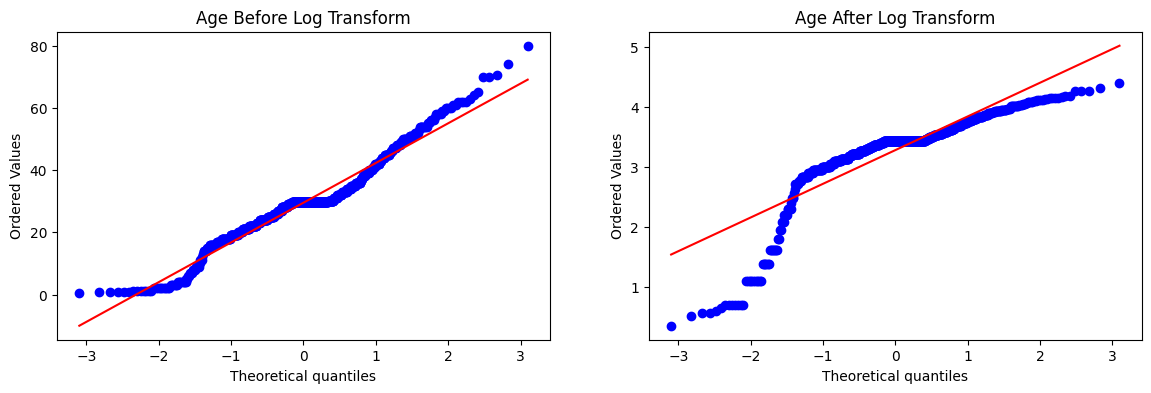

In [22]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age Before Log Transform')
plt.subplot(122)
stats.probplot(X_train_transformed['Age'],dist='norm',plot=plt)
plt.title('Age After Log Transform')
plt.show()